# 02. Campaign Performance Analysis

Analyze campaign, platform, ad-type, funnel, and time-trend performance. Outputs are suitable for Tableau.

In [3]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

campaigns = pd.read_csv(DATA_DIR / "campaigns_clean.csv")
ads = pd.read_csv(DATA_DIR / "ads_clean.csv")
users = pd.read_csv(DATA_DIR / "users_clean.csv")
ad_events = pd.read_csv(DATA_DIR / "ad_events_clean.csv")

ad_events["event_datetime"] = pd.to_datetime(ad_events["event_datetime"], errors="coerce")
ad_events["event_date"] = pd.to_datetime(ad_events["event_date"], errors="coerce")

display(campaigns.head())
display(ads.head())
display(ad_events.head())


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,25/05/2025,23/07/2025,59,24021.32
1,2,Campaign_2_Launch,16/04/2025,07/07/2025,82,79342.41
2,3,Campaign_3_Winter,04/05/2025,29/06/2025,56,14343.25
3,4,Campaign_4_Summer,04/06/2025,08/08/2025,65,45326.60
4,5,Campaign_5_Launch,11/07/2025,28/08/2025,48,68376.69


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology
3,4,28,Facebook,Stories,Female,25-34,news
4,5,24,Instagram,Image,Female,25-34,news


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,event_datetime,event_date,year,month,week,day_of_week_num
0,1,197,2359b,26/07/2025 0:19,Saturday,Night,Like,2025-07-26 00:19:00,2025-07-26,2025,2025-07,2025-07-21/2025-07-27,5
1,2,51,f9c67,15/06/2025 8:28,Sunday,Morning,Share,2025-06-15 08:28:00,2025-06-15,2025,2025-06,2025-06-09/2025-06-15,6
2,3,46,5b868,27/06/2025 0:40,Friday,Night,Impression,2025-06-27 00:40:00,2025-06-27,2025,2025-06,2025-06-23/2025-06-29,4
3,4,166,3d440,05/06/2025 19:20,Thursday,Evening,Impression,2025-06-05 19:20:00,2025-06-05,2025,2025-06,2025-06-02/2025-06-08,3
4,5,52,68f1a,22/07/2025 8:30,Tuesday,Morning,Impression,2025-07-22 08:30:00,2025-07-22,2025,2025-07,2025-07-21/2025-07-27,1


In [4]:

# ========== 1. Standardize Join Keys ==========
# IDs are identifiers, so always treat them as strings.
for df in [campaigns, ads, users, ad_events]:
    for col in ["user_id", "ad_id", "campaign_id"]:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()
            df[col] = df[col].replace({
                "nan": pd.NA,
                "None": pd.NA,
                "": pd.NA
            })

# ========== 2. Add Useful Flags ==========
ad_events["is_impression"] = (ad_events["event_type"] == "Impression").astype(int)
ad_events["is_click"] = (ad_events["event_type"] == "Click").astype(int)
ad_events["is_like"] = (ad_events["event_type"] == "Like").astype(int)
ad_events["is_share"] = (ad_events["event_type"] == "Share").astype(int)
ad_events["is_comment"] = (ad_events["event_type"] == "Comment").astype(int)
ad_events["is_engagement"] = ad_events["event_type"].isin(
    ["Like", "Share", "Comment"]
).astype(int)
ad_events["is_purchase"] = (ad_events["event_type"] == "Purchase").astype(int)

# ========== 3. Join Ad / Campaign / User Metadata ==========
analysis = (
    ad_events
    .merge(
        ads,
        on="ad_id",
        how="left",
        suffixes=("", "_ad")
    )
    .merge(
        campaigns,
        on="campaign_id",
        how="left",
        suffixes=("", "_campaign")
    )
)

if "user_id" in users.columns:
    analysis = analysis.merge(
        users,
        on="user_id",
        how="left",
        suffixes=("", "_user")
    )

# Relationship quality checks
print("analysis shape:", analysis.shape)

if "campaign_id" in analysis.columns:
    print("Missing campaign matches:",
          analysis["campaign_name"].isna().sum()
          if "campaign_name" in analysis.columns else "campaign_name column not available")

if "user_id" in analysis.columns:
    user_match_cols = [c for c in users.columns if c != "user_id"]
    if user_match_cols:
        print("Rows with no matched user profile:",
              analysis[user_match_cols].isna().all(axis=1).sum())


analysis shape: (119711, 37)
Missing campaign matches: campaign_name column not available
Rows with no matched user profile: 119711


In [5]:

# ========== 2. KPI Helper ==========
def safe_divide(a, b):
    return np.where(b != 0, a / b, np.nan)

def add_kpis(df):
    out = df.copy()
    out["CTR"] = safe_divide(out["clicks"], out["impressions"])
    out["CVR"] = safe_divide(out["purchases"], out["clicks"])
    out["Purchase_Rate"] = safe_divide(out["purchases"], out["impressions"])
    out["Engagement_Rate"] = safe_divide(out["engagements"], out["impressions"])
    return out


In [6]:

# ========== 3. Overall KPI ==========
overall = pd.DataFrame({
    "metric": [
        "Impressions", "Clicks", "Engagements", "Purchases"
    ],
    "value": [
        analysis["is_impression"].sum(),
        analysis["is_click"].sum(),
        analysis["is_engagement"].sum(),
        analysis["is_purchase"].sum()
    ]
})

overall.loc[len(overall)] = ["CTR", overall.loc[1, "value"] / overall.loc[0, "value"]]
overall.loc[len(overall)] = ["CVR", overall.loc[3, "value"] / overall.loc[1, "value"]]
overall.loc[len(overall)] = ["Purchase Rate", overall.loc[3, "value"] / overall.loc[0, "value"]]

display(overall)
overall.to_csv(OUTPUT_DIR / "overall_kpi.csv", index=False)


,metric,value
0,Impressions,101604.000000
1,Clicks,11951.000000
2,Engagements,5548.000000
3,Purchases,608.000000
4,CTR,0.117623
5,CVR,0.050874
6,Purchase Rate,0.005984


In [7]:

# ========== 4. Campaign KPI ==========
campaign_kpi = (
    analysis.groupby(
        ["campaign_id"] + ([c for c in ["campaign_name"] if c in analysis.columns]) +
        ([c for c in ["platform"] if c in analysis.columns]),
        dropna=False
    )
    .agg(
        impressions=("is_impression", "sum"),
        clicks=("is_click", "sum"),
        engagements=("is_engagement", "sum"),
        purchases=("is_purchase", "sum")
    )
    .reset_index()
)

campaign_kpi = add_kpis(campaign_kpi)

# Campaign budget is campaign-level. Use MAX, not SUM, after event-level joins.
if "total_budget" in campaigns.columns:
    budget = campaigns[["campaign_id", "total_budget"]].drop_duplicates("campaign_id")
    campaign_kpi = campaign_kpi.merge(budget, on="campaign_id", how="left")
    campaign_kpi["Budget_per_Purchase"] = campaign_kpi["total_budget"] / campaign_kpi["purchases"].replace(0, np.nan)

display(campaign_kpi.sort_values("purchases", ascending=False).head(20))
campaign_kpi.to_csv(OUTPUT_DIR / "campaign_kpi.csv", index=False)


,campaign_id,impressions,clicks,engagements,purchases,CTR,CVR,Purchase_Rate,Engagement_Rate,total_budget,Budget_per_Purchase
25,33,3690,416,213,33,0.112737,0.079327,0.008943,0.057724,59264.68,1795.899394
7,17,4054,503,218,30,0.124075,0.059642,0.007400,0.053774,86675.92,2889.197333
15,24,4120,460,187,20,0.111650,0.043478,0.004854,0.045388,56692.87,2834.643500
16,25,2546,304,145,19,0.119403,0.062500,0.007463,0.056952,52725.49,2775.025789
4,13,3037,326,171,19,0.107343,0.058282,0.006256,0.056306,21855.42,1150.285263
29,37,2997,362,153,18,0.120787,0.049724,0.006006,0.051051,46445.20,2580.288889
26,34,3087,375,159,17,0.121477,0.045333,0.005507,0.051506,26104.30,1535.547059
13,22,2536,317,144,17,0.125000,0.053628,0.006703,0.056782,35743.40,2102.552941
12,21,2022,257,102,17,0.127102,0.066148,0.008408,0.050445,37290.81,2193.577059
11,20,4023,489,193,17,0.121551,0.034765,0.004226,0.047974,98904.66,5817.921176


In [8]:

# ========== 5. Platform KPI ==========
if "platform" in analysis.columns:
    platform_kpi = (
        analysis.groupby("platform", dropna=False)
        .agg(
            impressions=("is_impression", "sum"),
            clicks=("is_click", "sum"),
            engagements=("is_engagement", "sum"),
            purchases=("is_purchase", "sum")
        )
        .reset_index()
    )
    platform_kpi = add_kpis(platform_kpi)
    display(platform_kpi.sort_values("CVR", ascending=False))
    platform_kpi.to_csv(OUTPUT_DIR / "platform_kpi.csv", index=False)
else:
    platform_kpi = pd.DataFrame()


In [9]:

# ========== 6. Ad Type KPI ==========
if "ad_type" in analysis.columns:
    ad_type_kpi = (
        analysis.groupby("ad_type", dropna=False)
        .agg(
            impressions=("is_impression", "sum"),
            clicks=("is_click", "sum"),
            engagements=("is_engagement", "sum"),
            purchases=("is_purchase", "sum")
        )
        .reset_index()
    )
    ad_type_kpi = add_kpis(ad_type_kpi)
    display(ad_type_kpi.sort_values("CVR", ascending=False))
    ad_type_kpi.to_csv(OUTPUT_DIR / "ad_type_kpi.csv", index=False)
else:
    ad_type_kpi = pd.DataFrame()


,ad_type,impressions,clicks,engagements,purchases,CTR,CVR,Purchase_Rate,Engagement_Rate
3,Video,16824,1942,883,111,0.115430,0.057158,0.006598,0.052485
2,Stories,32473,3800,1799,211,0.117020,0.055526,0.006498,0.055400
0,Carousel,26088,3042,1395,147,0.116605,0.048323,0.005635,0.053473
1,Image,26219,3167,1471,139,0.120790,0.043890,0.005301,0.056104


In [10]:

# ========== 7. Funnel Analysis ==========
funnel = pd.DataFrame({
    "stage": ["Impression", "Click", "Engagement", "Purchase"],
    "users_or_events": [
        analysis.loc[analysis["is_impression"].eq(1), "user_id"].nunique()
        if "user_id" in analysis.columns else analysis["is_impression"].sum(),

        analysis.loc[analysis["is_click"].eq(1), "user_id"].nunique()
        if "user_id" in analysis.columns else analysis["is_click"].sum(),

        analysis.loc[analysis["is_engagement"].eq(1), "user_id"].nunique()
        if "user_id" in analysis.columns else analysis["is_engagement"].sum(),

        analysis.loc[analysis["is_purchase"].eq(1), "user_id"].nunique()
        if "user_id" in analysis.columns else analysis["is_purchase"].sum()
    ]
})

funnel["step_conversion"] = np.nan
for i in range(1, len(funnel)):
    funnel.loc[i, "step_conversion"] = (
        funnel.loc[i, "users_or_events"] /
        funnel.loc[i-1, "users_or_events"]
        if funnel.loc[i-1, "users_or_events"] != 0 else np.nan
    )

funnel["overall_conversion_from_impression"] = (
    funnel["users_or_events"] / funnel.loc[0, "users_or_events"]
)

display(funnel)
funnel.to_csv(OUTPUT_DIR / "funnel.csv", index=False)


,stage,users_or_events,step_conversion,overall_conversion_from_impression
0,Impression,9945,NaN,1.000000
1,Click,6981,0.701961,0.701961
2,Engagement,4269,0.611517,0.429261
3,Purchase,593,0.138908,0.059628


In [11]:

# ========== 8. Daily Time Trend ==========
daily = (
    analysis.groupby("event_date")
    .agg(
        impressions=("is_impression", "sum"),
        clicks=("is_click", "sum"),
        engagements=("is_engagement", "sum"),
        purchases=("is_purchase", "sum")
    )
    .reset_index()
    .sort_values("event_date")
)

daily = add_kpis(daily)
display(daily.head(10))
daily.to_csv(OUTPUT_DIR / "daily_trend.csv", index=False)


,event_date,impressions,clicks,engagements,purchases,CTR,CVR,Purchase_Rate,Engagement_Rate
0,2025-05-07,487,59,29,2,0.121150,0.033898,0.004107,0.059548
1,2025-05-08,1072,114,61,10,0.106343,0.087719,0.009328,0.056903
2,2025-05-09,1105,149,51,6,0.134842,0.040268,0.005430,0.046154
3,2025-05-10,1104,133,75,3,0.120471,0.022556,0.002717,0.067935
4,2025-05-11,1120,136,53,7,0.121429,0.051471,0.006250,0.047321
5,2025-05-12,1113,129,49,3,0.115903,0.023256,0.002695,0.044025
6,2025-05-13,1093,138,65,7,0.126258,0.050725,0.006404,0.059469
7,2025-05-14,1085,141,73,4,0.129954,0.028369,0.003687,0.067281
8,2025-05-15,1140,127,64,4,0.111404,0.031496,0.003509,0.056140
9,2025-05-16,1103,145,57,5,0.131460,0.034483,0.004533,0.051677


In [12]:

# ========== 9. Day-of-Week & Time-of-Day ==========
if "day_of_week" in analysis.columns:
    dow = (
        analysis.groupby("day_of_week", observed=False)
        .agg(
            impressions=("is_impression", "sum"),
            clicks=("is_click", "sum"),
            purchases=("is_purchase", "sum")
        )
        .reset_index()
    )
    dow = add_kpis(dow.rename(columns={"purchases": "purchases"}).assign(engagements=0))
    dow.to_csv(OUTPUT_DIR / "day_of_week_kpi.csv", index=False)
    display(dow)

if "time_of_day" in analysis.columns:
    tod = (
        analysis.groupby("time_of_day", observed=False)
        .agg(
            impressions=("is_impression", "sum"),
            clicks=("is_click", "sum"),
            purchases=("is_purchase", "sum")
        )
        .reset_index()
    )
    tod["CTR"] = safe_divide(tod["clicks"], tod["impressions"])
    tod["CVR"] = safe_divide(tod["purchases"], tod["clicks"])
    tod.to_csv(OUTPUT_DIR / "time_of_day_kpi.csv", index=False)
    display(tod)


,day_of_week,impressions,clicks,purchases,engagements,CTR,CVR,Purchase_Rate,Engagement_Rate
0,Friday,14473,1779,94,0,0.122919,0.052839,0.006495,0.0
1,Monday,14593,1684,78,0,0.115398,0.046318,0.005345,0.0
2,Saturday,14444,1674,91,0,0.115896,0.054361,0.006300,0.0
3,Sunday,14507,1681,78,0,0.115875,0.046401,0.005377,0.0
4,Thursday,14538,1671,100,0,0.114940,0.059844,0.006879,0.0
5,Tuesday,14435,1739,87,0,0.120471,0.050029,0.006027,0.0
6,Wednesday,14614,1723,80,0,0.117901,0.046431,0.005474,0.0


,time_of_day,impressions,clicks,purchases,CTR,CVR
0,Afternoon,25540,3069,157,0.120164,0.051157
1,Evening,25162,2932,144,0.116525,0.049113
2,Morning,25554,2954,148,0.115598,0.050102
3,Night,25348,2996,159,0.118195,0.053071


In [13]:

# ========== 10. Audience KPI ==========
audience_cols = [c for c in ["age", "gender", "country", "device"] if c in analysis.columns]

for col in audience_cols:
    tmp = (
        analysis.groupby(col, dropna=False)
        .agg(
            impressions=("is_impression", "sum"),
            clicks=("is_click", "sum"),
            purchases=("is_purchase", "sum")
        )
        .reset_index()
    )
    tmp["CTR"] = safe_divide(tmp["clicks"], tmp["impressions"])
    tmp["CVR"] = safe_divide(tmp["purchases"], tmp["clicks"])
    tmp.to_csv(OUTPUT_DIR / f"audience_{col}_kpi.csv", index=False)
    print(f"\n--- {col} ---")
    display(tmp.sort_values("CVR", ascending=False).head(15))



--- country ---


,country,impressions,clicks,purchases,CTR,CVR
0,NaN,101604,11951,608,0.117623,0.050874


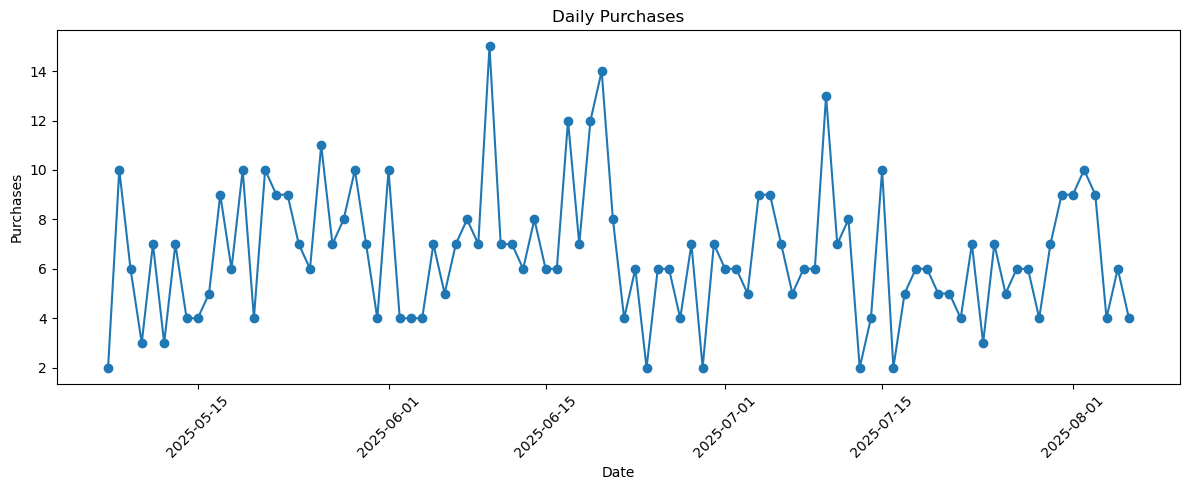

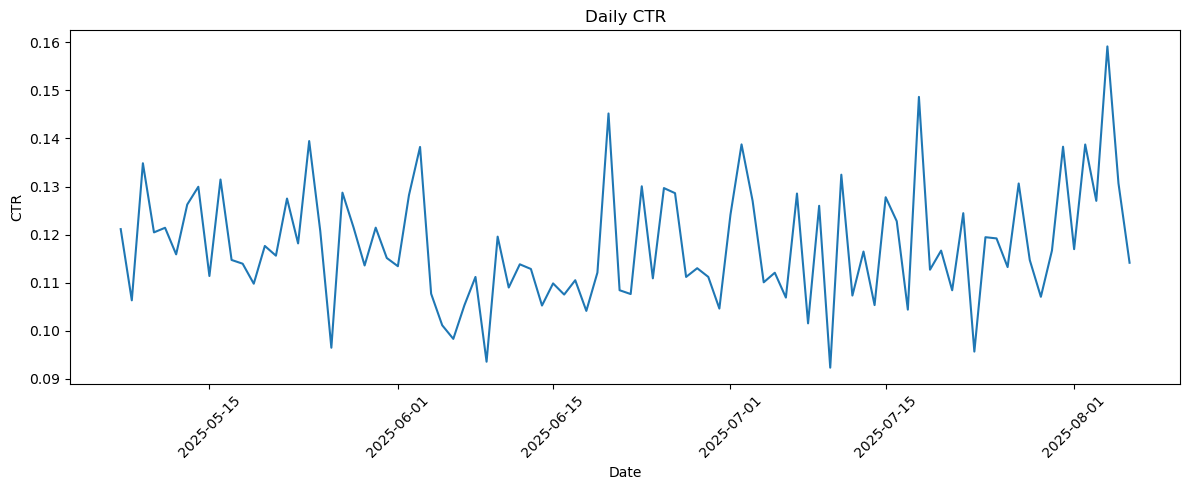

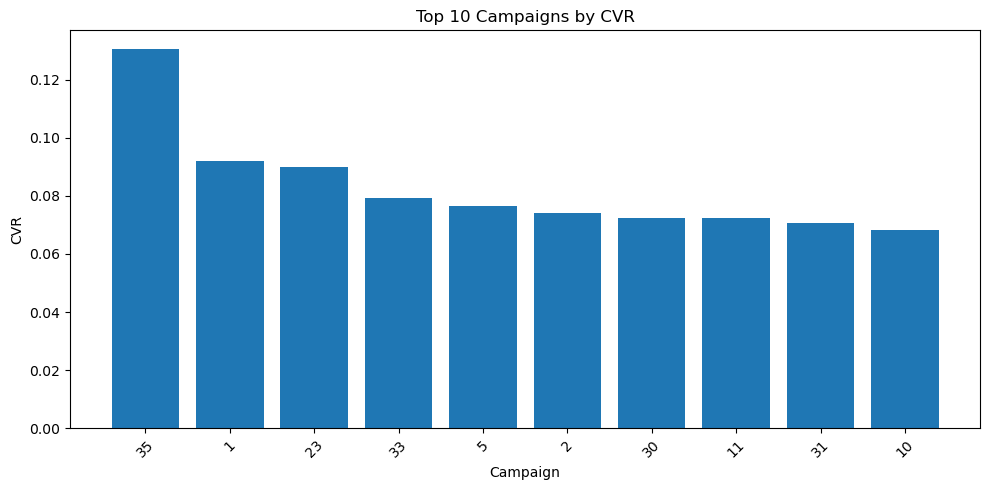

In [14]:

# ========== 11. Visual Analysis ==========
# Daily purchases
plt.figure(figsize=(12, 5))
plt.plot(daily["event_date"], daily["purchases"], marker="o", linewidth=1.5)
plt.title("Daily Purchases")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Daily CTR
plt.figure(figsize=(12, 5))
plt.plot(daily["event_date"], daily["CTR"], linewidth=1.5)
plt.title("Daily CTR")
plt.xlabel("Date")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Campaign CVR
top_campaigns = campaign_kpi.sort_values("CVR", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_campaigns["campaign_id"].astype(str), top_campaigns["CVR"])
plt.title("Top 10 Campaigns by CVR")
plt.xlabel("Campaign")
plt.ylabel("CVR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:

# ========== 12. Simple Business Insight Table ==========
insights = []

if not platform_kpi.empty:
    top_ctr_platform = platform_kpi.loc[platform_kpi["CTR"].idxmax(), "platform"]
    top_cvr_platform = platform_kpi.loc[platform_kpi["CVR"].idxmax(), "platform"]
    insights.append(["Platform with highest CTR", top_ctr_platform])
    insights.append(["Platform with highest CVR", top_cvr_platform])

if not ad_type_kpi.empty:
    top_cvr_ad = ad_type_kpi.loc[ad_type_kpi["CVR"].idxmax(), "ad_type"]
    insights.append(["Ad type with highest CVR", top_cvr_ad])

top_campaign = campaign_kpi.sort_values("purchases", ascending=False).iloc[0]
insights.append(["Campaign with most purchases", top_campaign["campaign_id"]])

insights_df = pd.DataFrame(insights, columns=["finding", "value"])
display(insights_df)
insights_df.to_csv(OUTPUT_DIR / "business_insights_summary.csv", index=False)


,finding,value
0,Ad type with highest CVR,Video
1,Campaign with most purchases,33
